In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

YEAR = 2025
PROVINCIAS = None
USE_PROXY = True
METRIC = "median"
KWH_PER_100KM = 17.0
SAVE_FIGS = True

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
from pathlib import Path

REPO_ROOT = Path(r"Script_Ingesta").resolve()
DATA_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR  = REPO_ROOT / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT.as_posix())
print("DATA_DIR :", DATA_DIR.as_posix())
print("FIG_DIR  :", FIG_DIR.as_posix())

REPO_ROOT: C:/Users/Jon/Documents/Repositorios/Proyectos_DS2025/Script_Ingesta/Script_Ingesta
DATA_DIR : C:/Users/Jon/Documents/Repositorios/Proyectos_DS2025/Script_Ingesta/Script_Ingesta/data/processed
FIG_DIR  : C:/Users/Jon/Documents/Repositorios/Proyectos_DS2025/Script_Ingesta/Script_Ingesta/figures


In [3]:
def _wide_proxy_path(year:int) -> Path:
    return DATA_DIR / f"ocm_proxy_{year}_wide.csv"

def _wide_metric_path(year:int, metric:str) -> Path:
    metric = "median" if metric == "median" else "mean"
    return DATA_DIR / f"ocm_curvas_{metric}_{year}_wide.csv"

def _build_from_monthlies(year:int, value_col:str) -> pd.DataFrame:
    files = sorted(DATA_DIR.glob(f"ocm_agg_{year}-*.csv"))
    if not files:
        raise SystemExit(f"No se encontraron mensuales 'ocm_agg_{year}-*.csv' en {DATA_DIR}.")
    parts = [pd.read_csv(fp) for fp in files]
    df = pd.concat(parts, ignore_index=True)
    level_col = "provincia" if "provincia" in df.columns else "ccaa"
    needed = {"month", level_col, "band", value_col}
    if not needed.issubset(df.columns):
        raise SystemExit(f"Faltan columnas en mensuales: {needed}")
    df["month"] = pd.to_datetime(df["month"], format="%Y-%m", errors="coerce")
    wide = (
        df.pivot_table(index=["month", level_col], columns="band", values=value_col)
          .reset_index()
          .sort_values([level_col, "month"])
    )
    for col in ["AC","DC"]:
        if col not in wide.columns:
            wide[col] = pd.NA
    if level_col == "ccaa":
        wide = wide.rename(columns={"ccaa":"provincia"})
    return wide

def load_wide(year:int, use_proxy:bool, metric:str) -> pd.DataFrame:
    if use_proxy:
        fp = _wide_proxy_path(year)
        if fp.exists():
            dfw = pd.read_csv(fp)
            if "provincia" not in dfw.columns and "ccaa" in dfw.columns:
                dfw = dfw.rename(columns={"ccaa":"provincia"})
            dfw["month"] = pd.to_datetime(dfw["month"], format="%Y-%m")
            return dfw.sort_values(["provincia","month"]).reset_index(drop=True)
    fp_wide = _wide_metric_path(year, metric)
    if fp_wide.exists():
        dfw = pd.read_csv(fp_wide)
        if "provincia" not in dfw.columns and "ccaa" in dfw.columns:
            dfw = dfw.rename(columns={"ccaa":"provincia"})
        dfw["month"] = pd.to_datetime(dfw["month"], format="%Y-%m")
        return dfw.sort_values(["provincia","month"]).reset_index(drop=True)
    val_col = "median_eur_kWh" if metric == "median" else "mean_eur_kWh"
    dfw = _build_from_monthlies(year, val_col)
    return dfw.sort_values(["provincia","month"]).reset_index(drop=True)

df_wide = load_wide(YEAR, USE_PROXY, METRIC)
prov_disponibles = sorted(df_wide["provincia"].dropna().unique().tolist())
if PROVINCIAS is None:
    PROVINCIAS = prov_disponibles
print("Provincias disponibles:", prov_disponibles[:10], "… total:", len(prov_disponibles))
df_wide.head()

SystemExit: No se encontraron mensuales 'ocm_agg_2025-*.csv' en C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\Script_Ingesta\data\processed.

C:\Users\Jon\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3557: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
def plot_prov(df_wide: pd.DataFrame, prov: str, year: int, kwh_per_100km=None, save_figs=True):
    sub = df_wide[(df_wide["provincia"] == prov) & (df_wide["month"].dt.year == year)].copy()
    if sub.empty:
        print(f"[WARN] Sin datos para '{prov}' en {year}.")
        return
    sub = sub.sort_values("month")

    fig1 = plt.figure()
    if "AC" in sub.columns:
        plt.plot(sub["month"], sub["AC"], marker="o", label="AC (€/kWh)")
    if "DC" in sub.columns:
        plt.plot(sub["month"], sub["DC"], marker="o", label="DC (€/kWh)")
    plt.title(f"{prov} · {year} · Precio EV (€/kWh)")
    plt.xlabel("Mes"); plt.ylabel("€/kWh")
    plt.xticks(rotation=45, ha="right"); plt.grid(True); plt.legend(); plt.tight_layout()
    if save_figs:
        out1 = FIG_DIR / f"ev_{prov.replace(' ', '_')}_{year}_eur_kWh.png"
        fig1.savefig(out1, dpi=150)
        print(f"[OK] Guardado: {out1}")

    if kwh_per_100km is not None:
        fig2 = plt.figure()
        if "AC" in sub.columns:
            plt.plot(sub["month"], sub["AC"] * kwh_per_100km, marker="o",
                     label=f"AC (€/100 km, {kwh_per_100km} kWh/100)")
        if "DC" in sub.columns:
            plt.plot(sub["month"], sub["DC"] * kwh_per_100km, marker="o",
                     label=f"DC (€/100 km, {kwh_per_100km} kWh/100)")
        plt.title(f"{prov} · {year} · Coste estimado (€/100 km)")
        plt.xlabel("Mes"); plt.ylabel("€/100 km")
        plt.xticks(rotation=45, ha="right"); plt.grid(True); plt.legend(); plt.tight_layout()
        if save_figs:
            out2 = FIG_DIR / f"ev_{prov.replace(' ', '_')}_{year}_eur_per_100km.png"
            fig2.savefig(out2, dpi=150)
            print(f"[OK] Guardado: {out2}")

Generando curvas para 18 CCAA: ['Andalucía', 'Aragón', 'Asturias', 'Canarias', 'Cantabria', 'Castilla y León', 'Castilla-La Mancha', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Comunidad de Madrid', 'Extremadura', 'Galicia', 'Illes Balears', 'La Rioja', 'Navarra', 'País Vasco', 'Región de Murcia']
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Andalucía_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Andalucía_2025_eur_per_100km.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Aragón_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Aragón_2025_eur_per_100km.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Asturias_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figure

C:\Users\Jon\AppData\Local\Temp\ipykernel_20524\2572527432.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1 = plt.figure()


[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Comunidad_de_Madrid_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Comunidad_de_Madrid_2025_eur_per_100km.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Extremadura_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Extremadura_2025_eur_per_100km.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Galicia_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Galicia_2025_eur_per_100km.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Illes_Balears_2025_eur_kWh.png
[OK] Guardado: C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Script_Ingesta\figures\ev_Illes_Balears_202

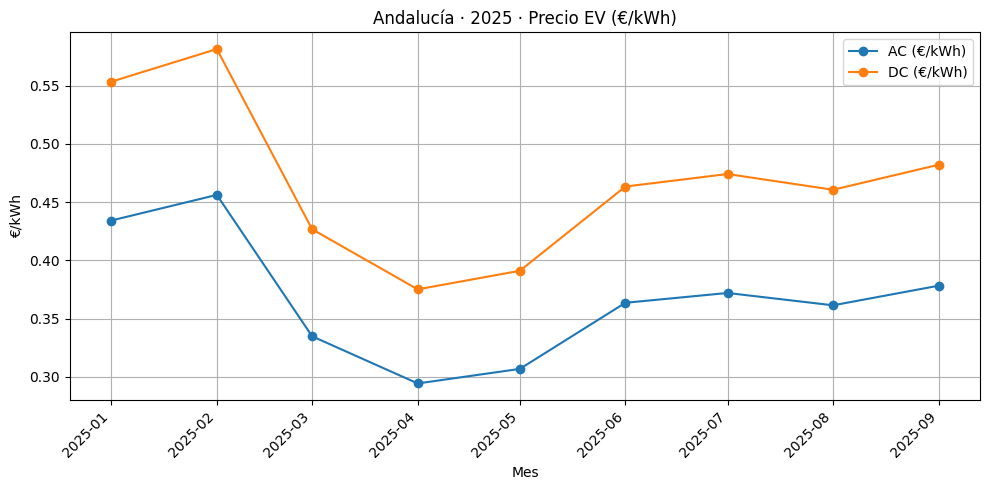

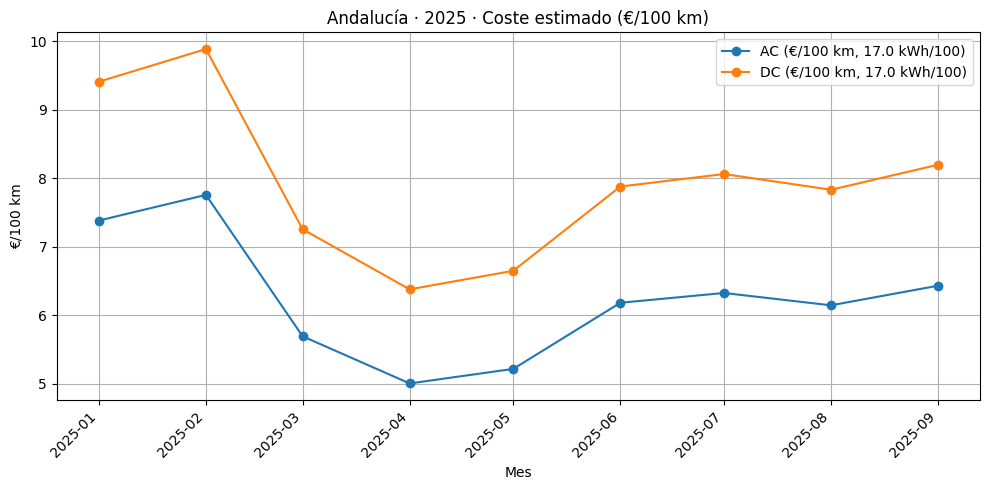

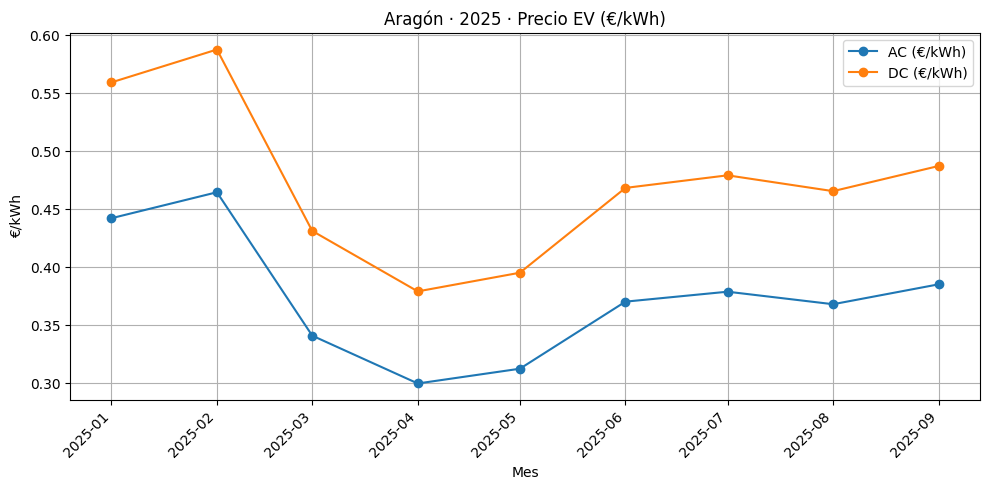

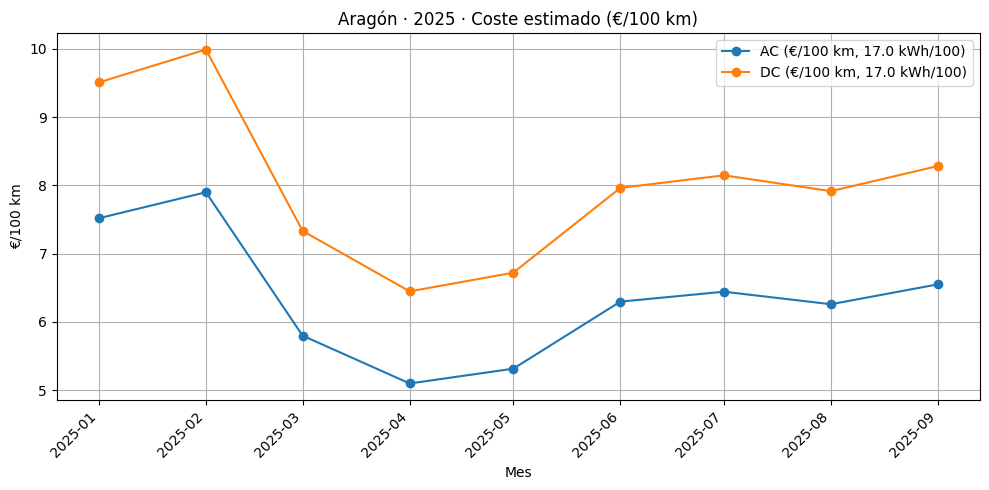

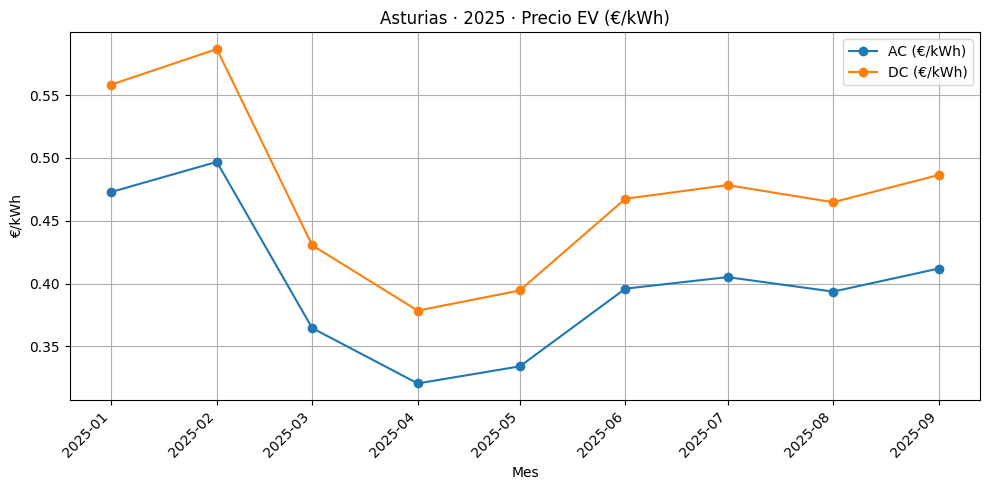

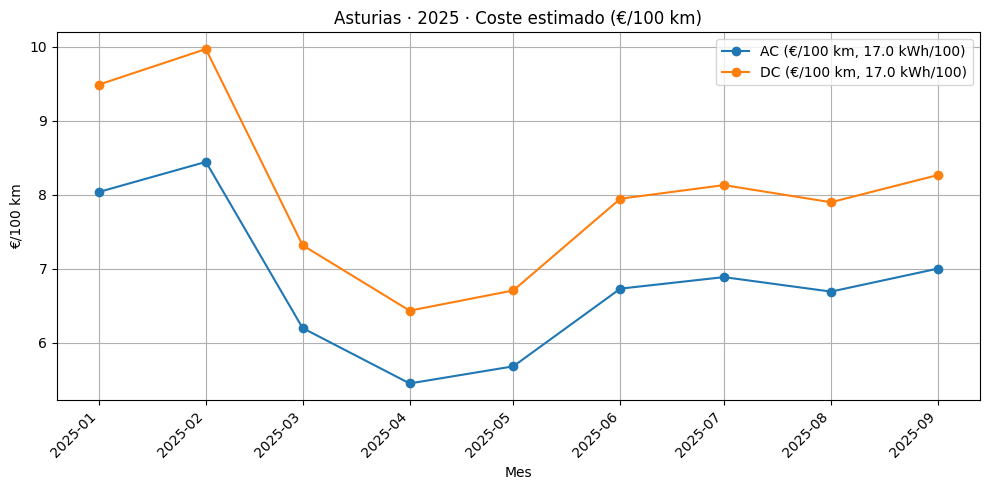

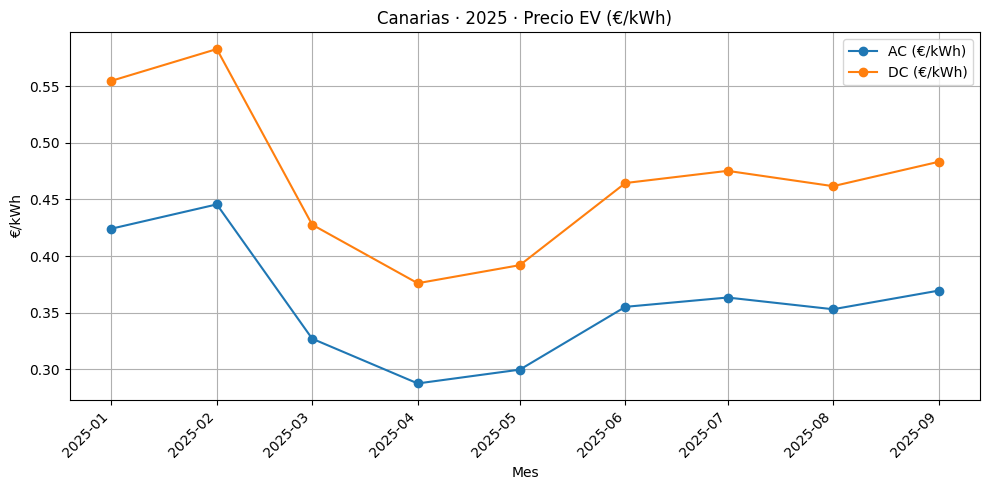

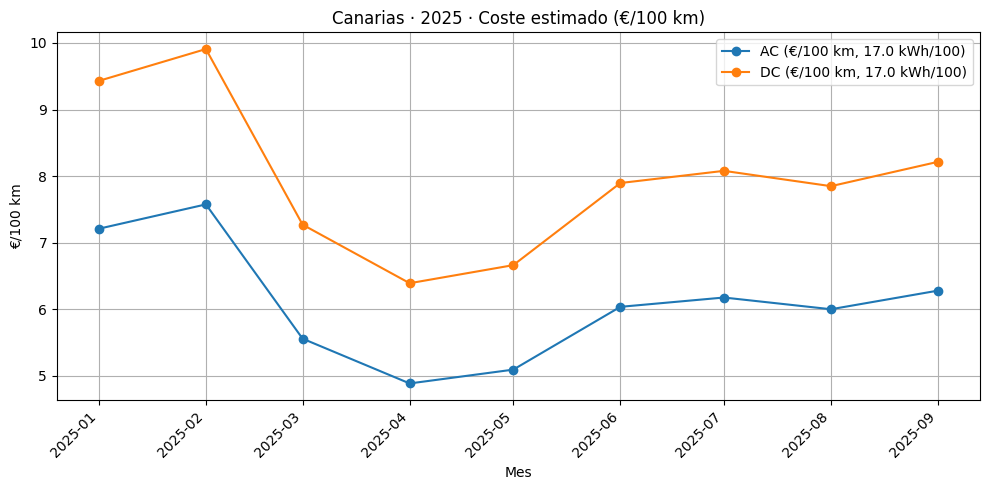

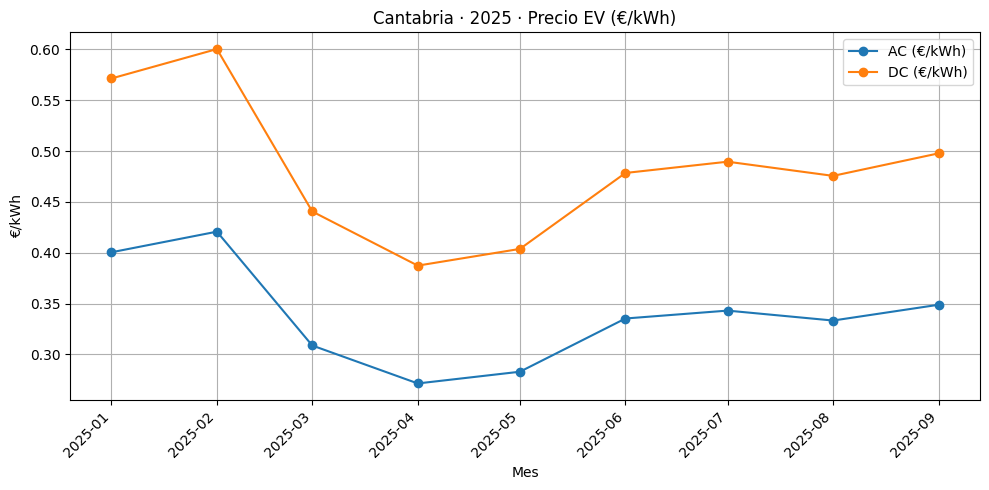

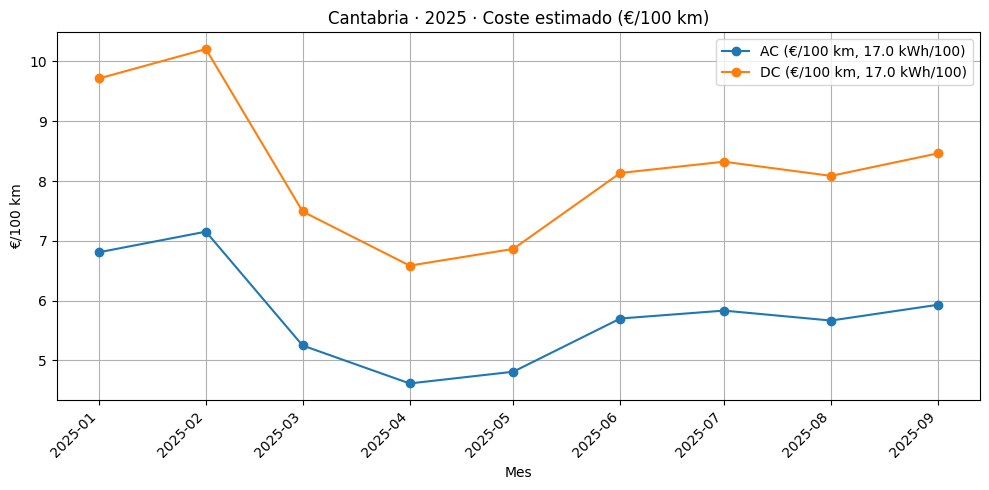

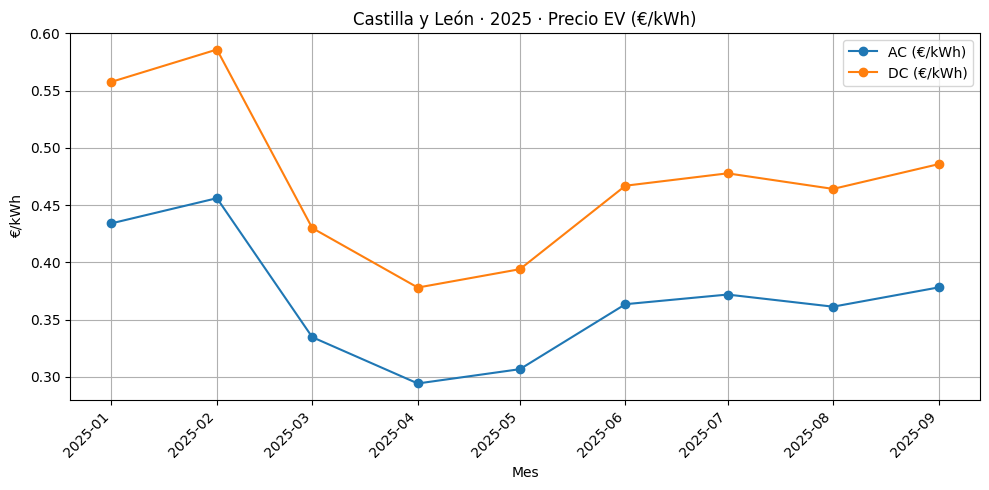

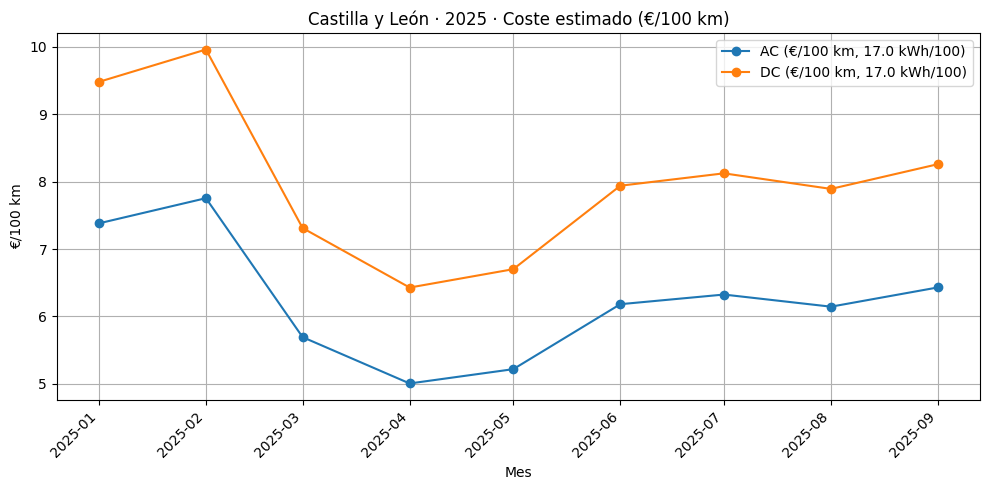

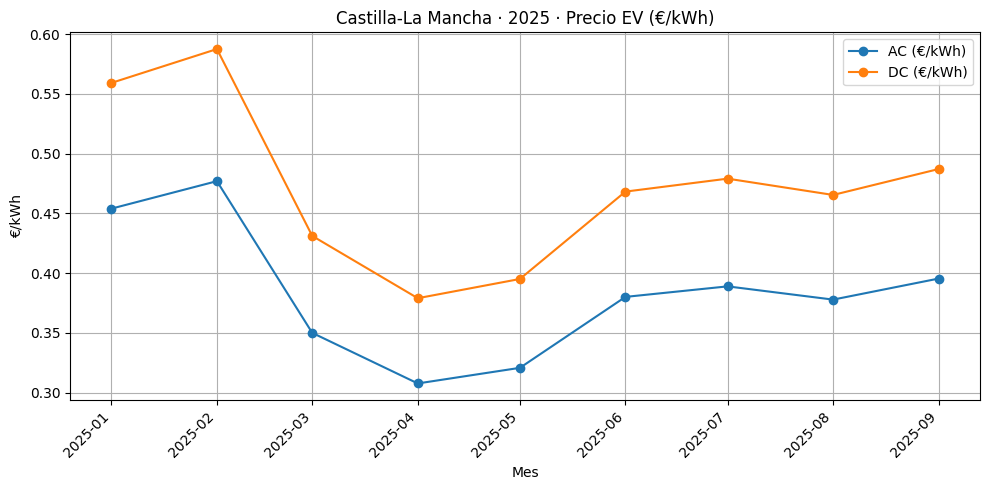

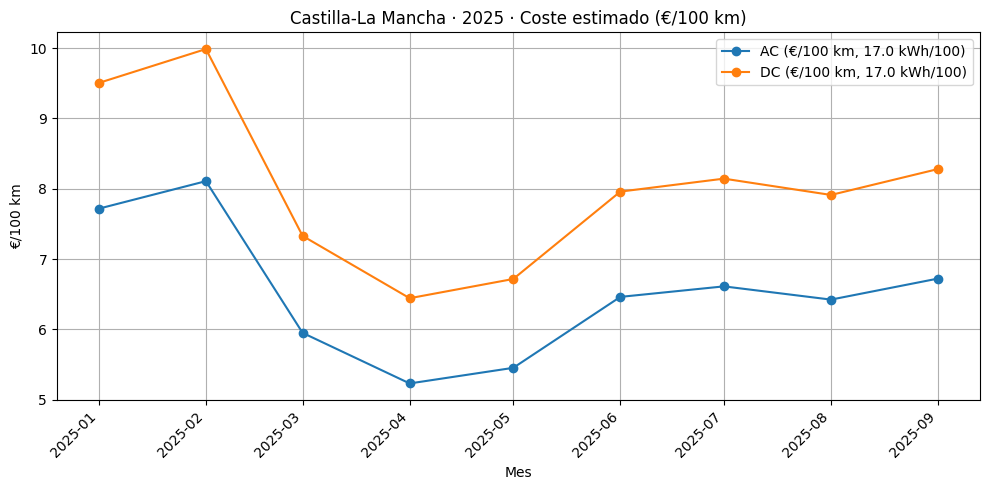

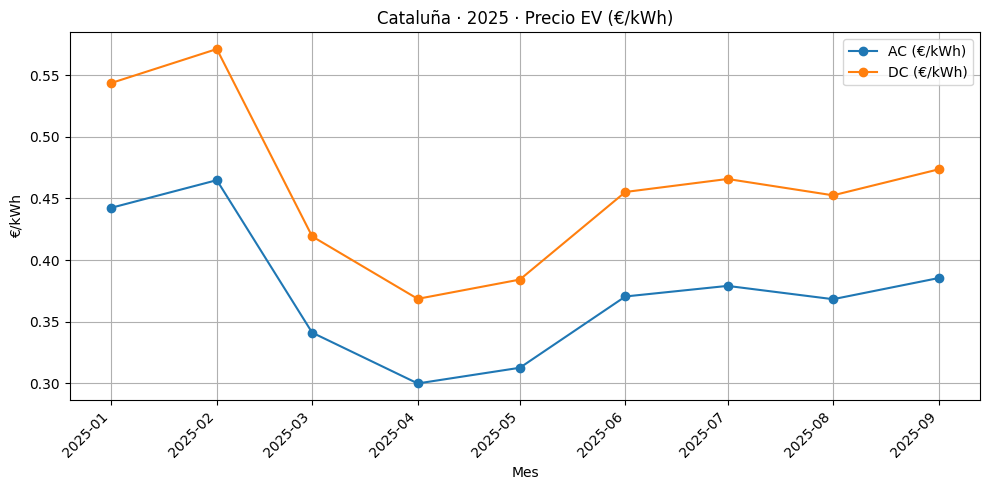

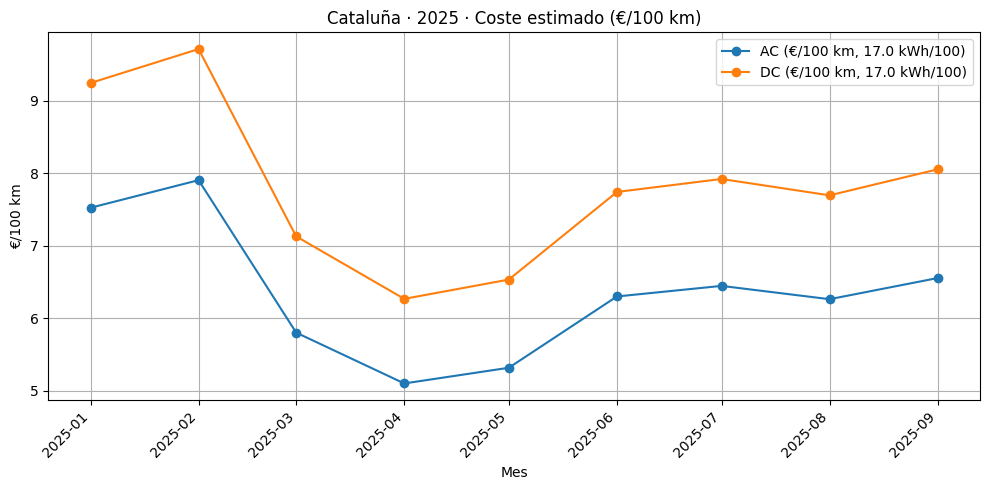

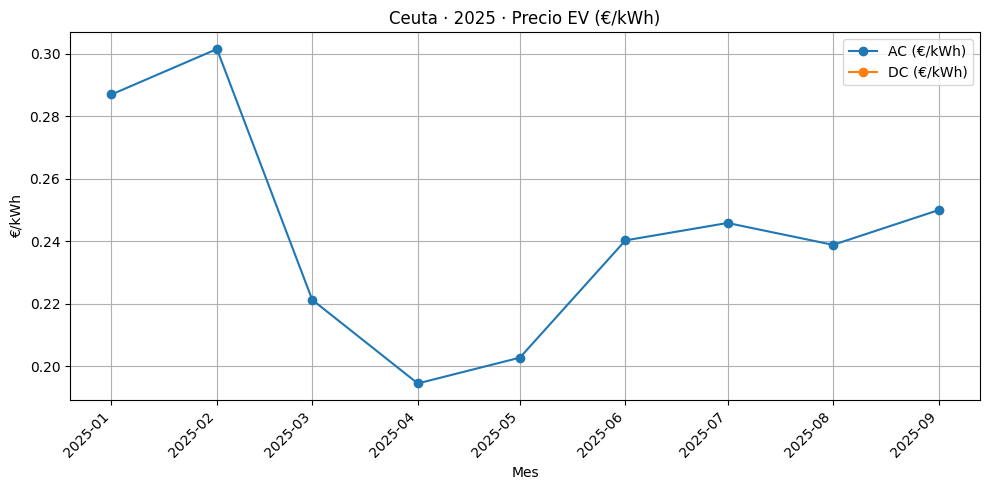

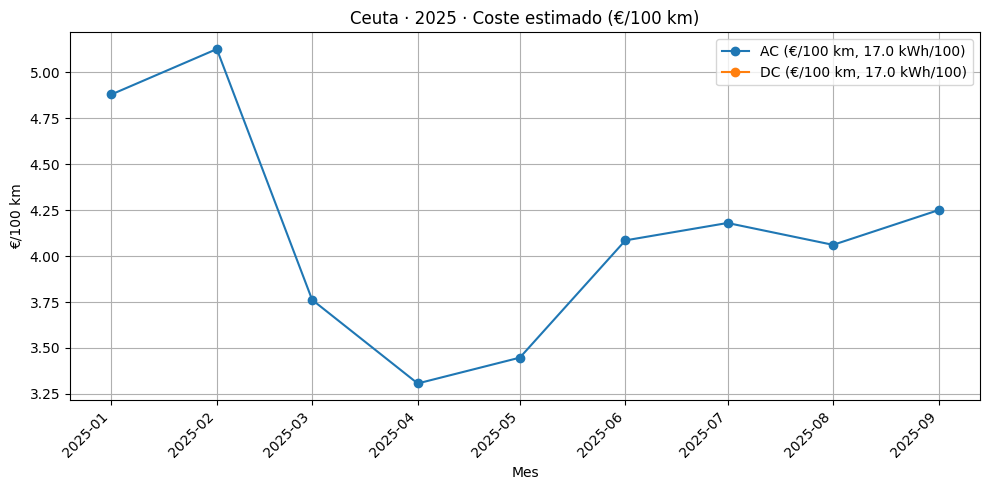

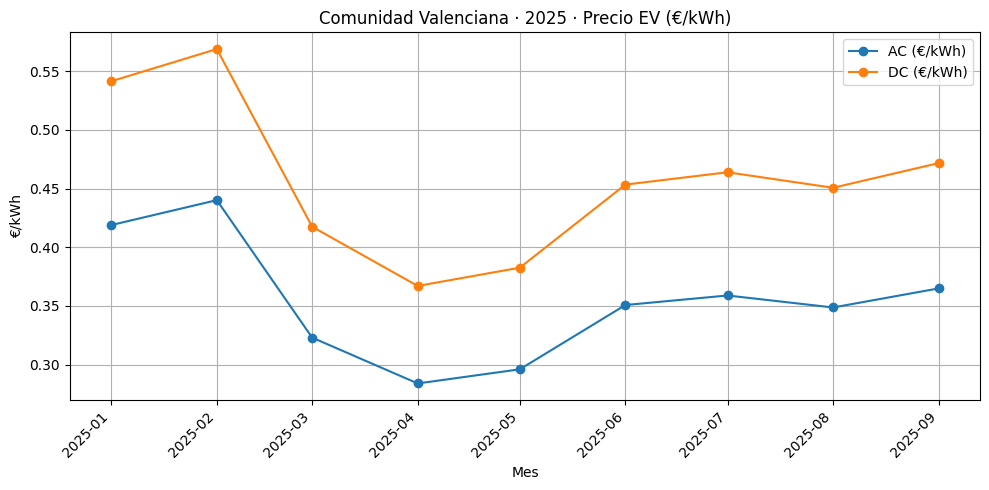

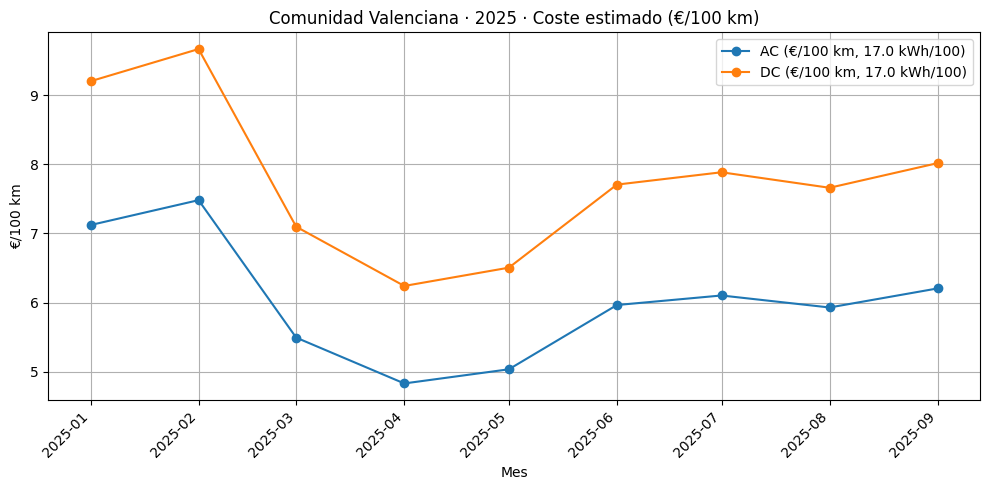

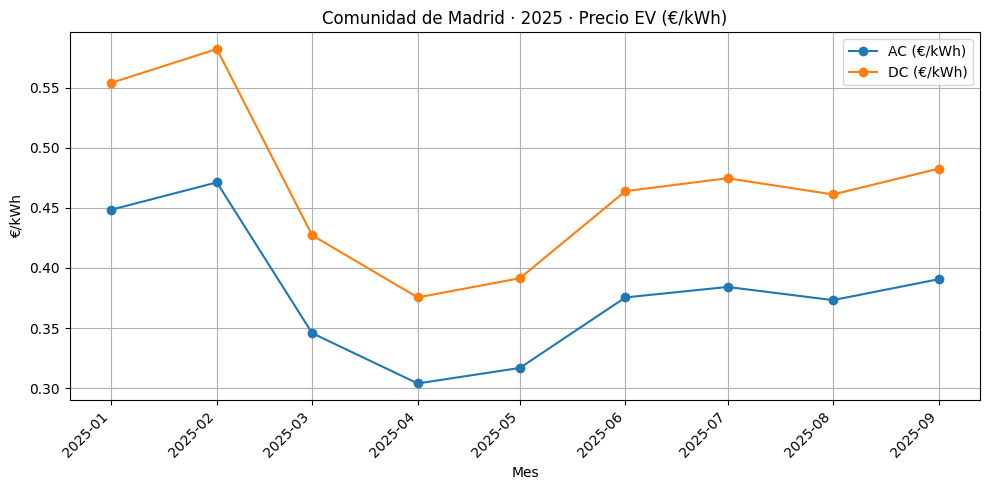

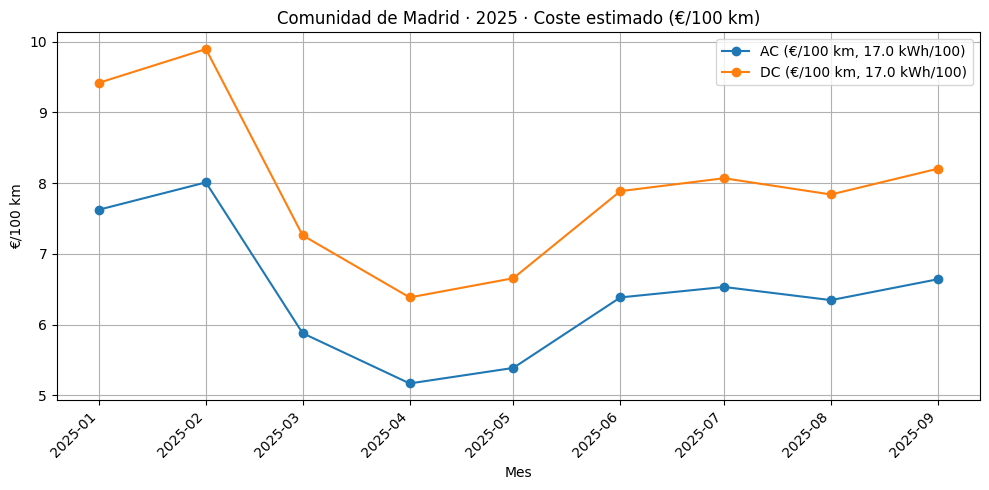

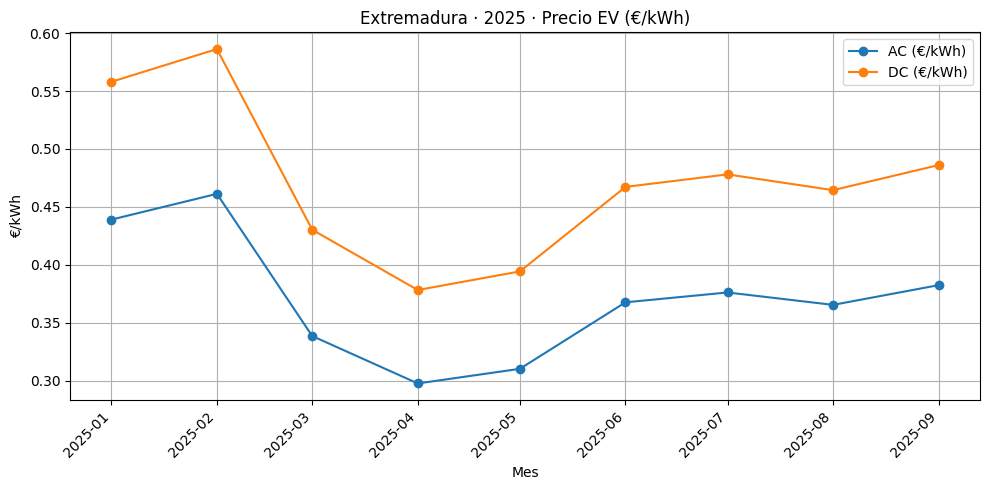

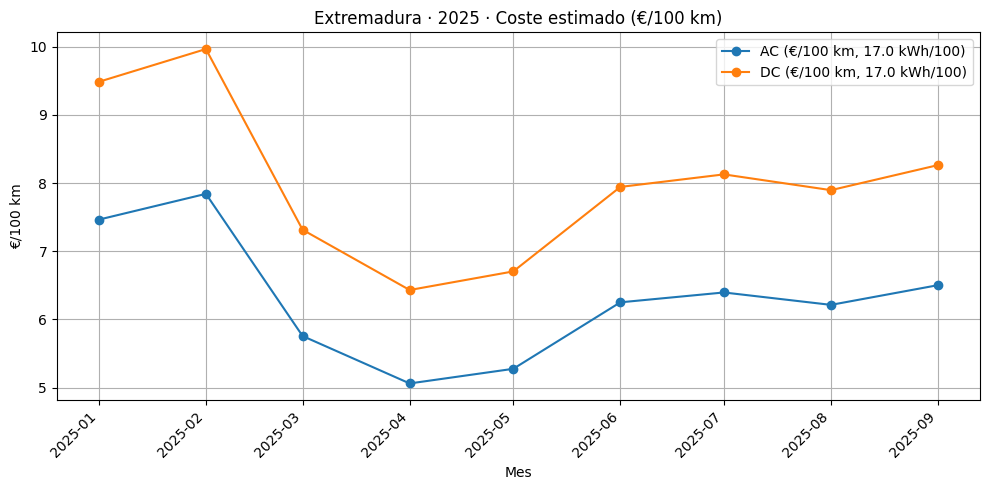

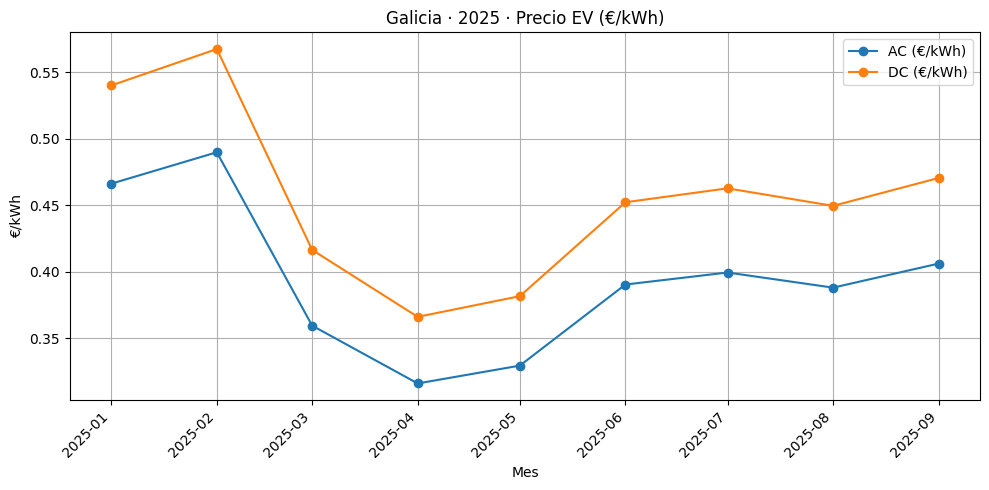

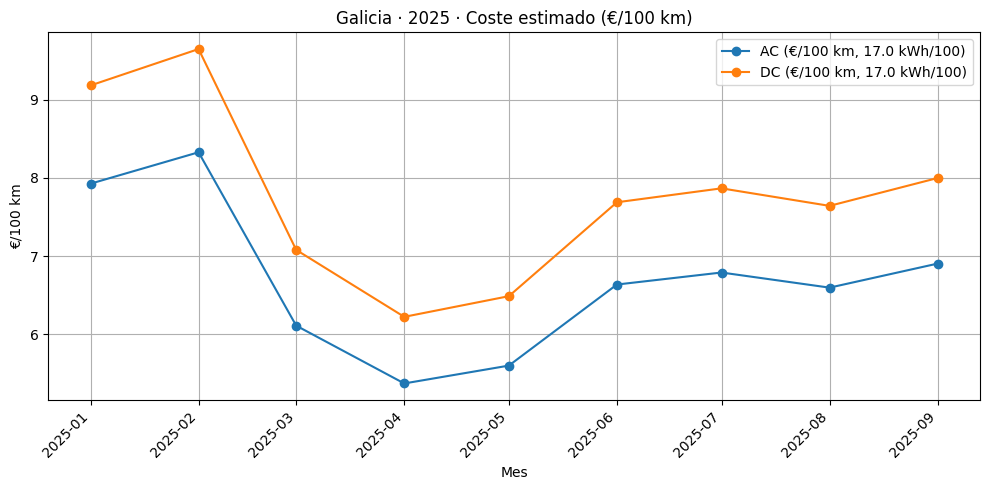

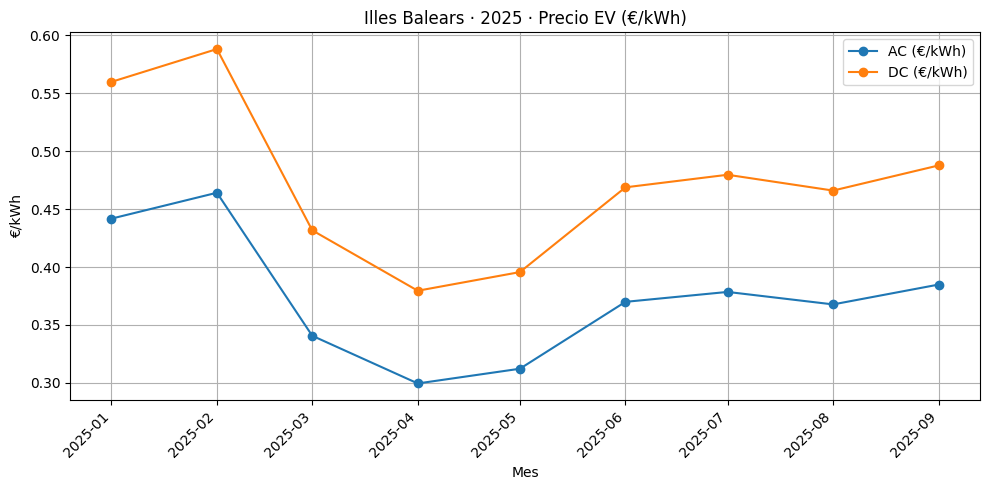

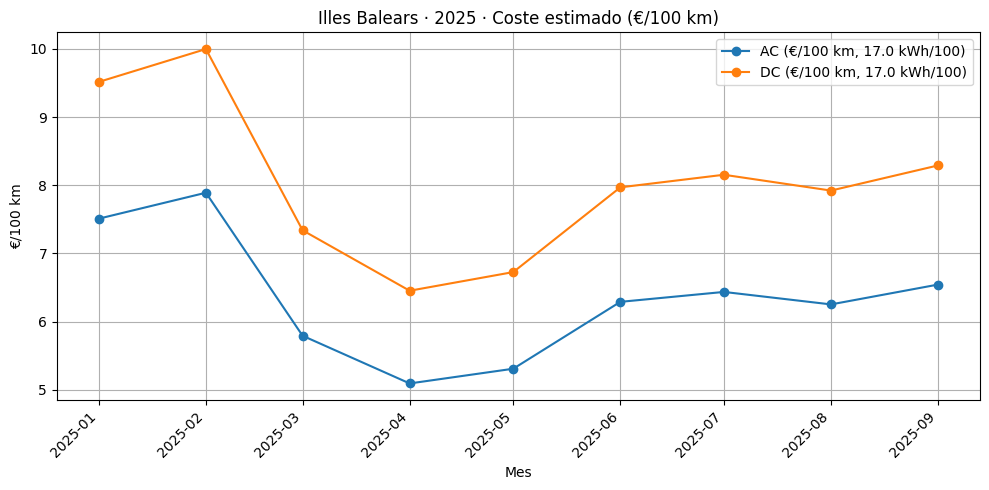

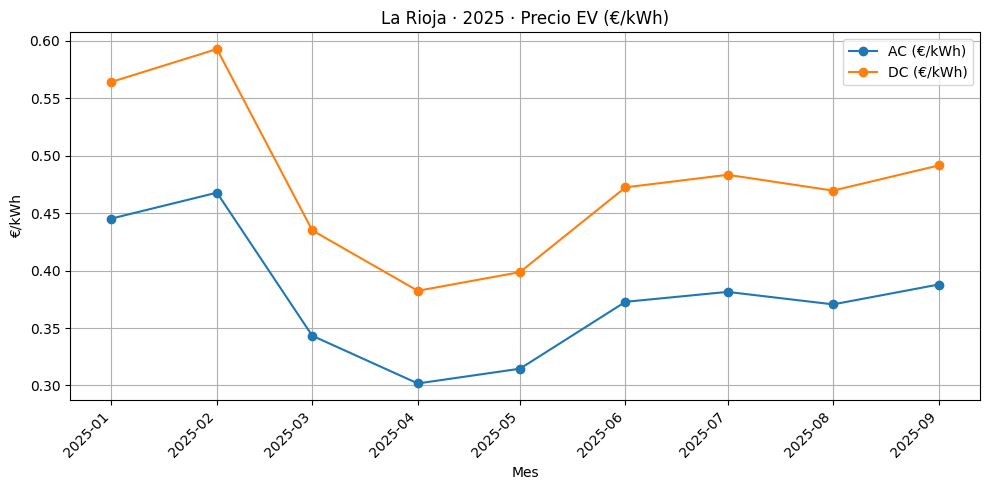

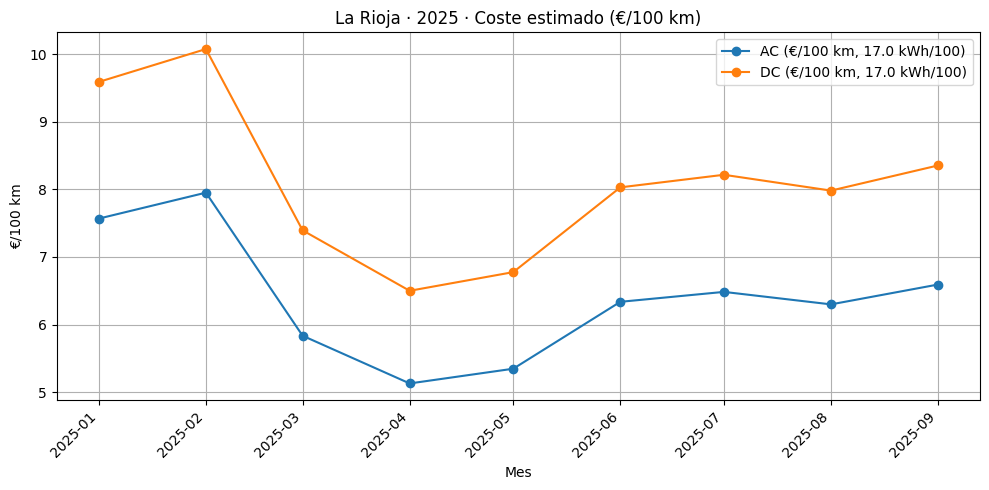

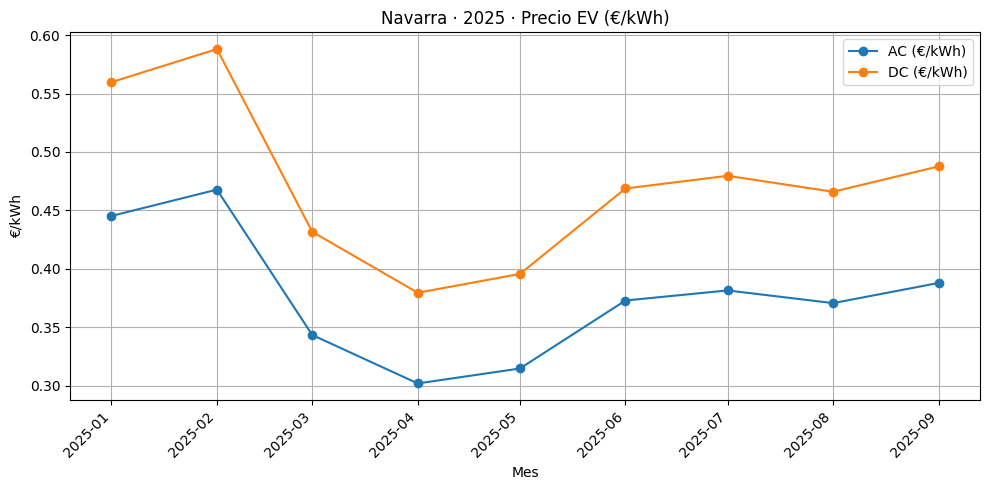

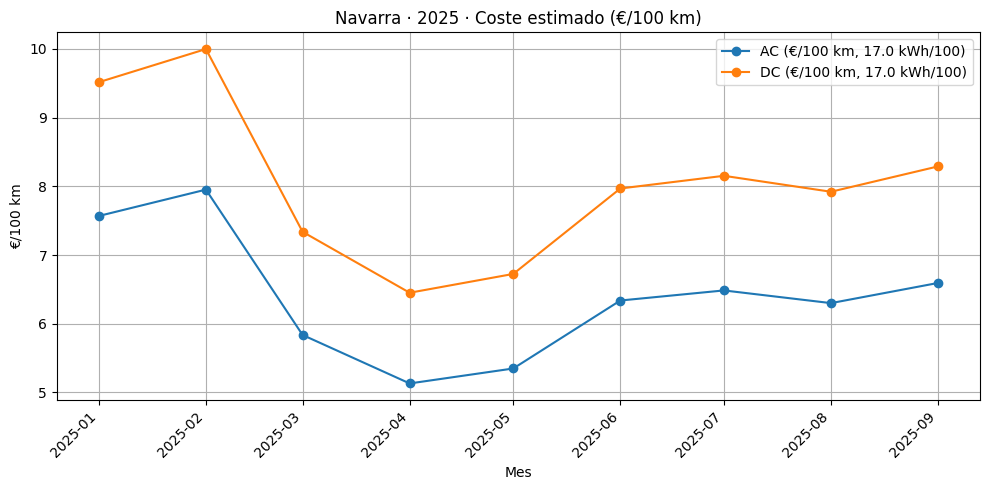

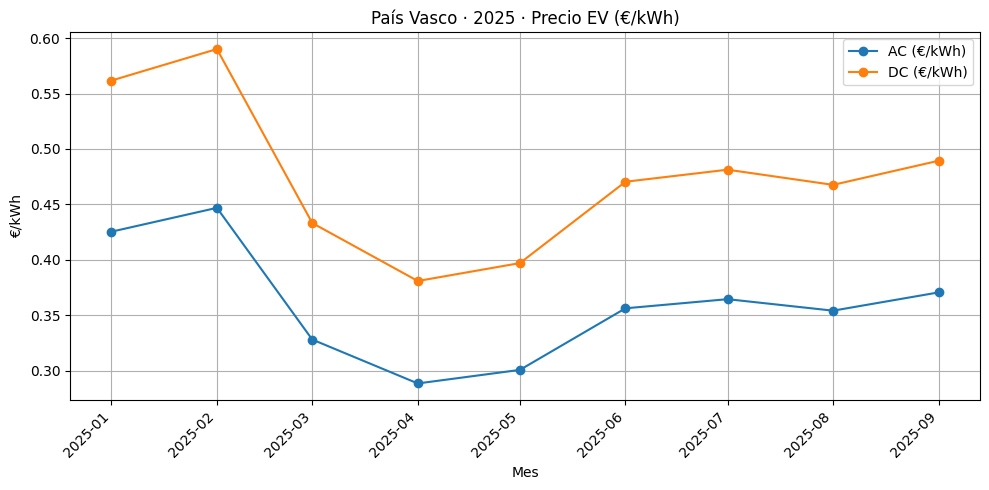

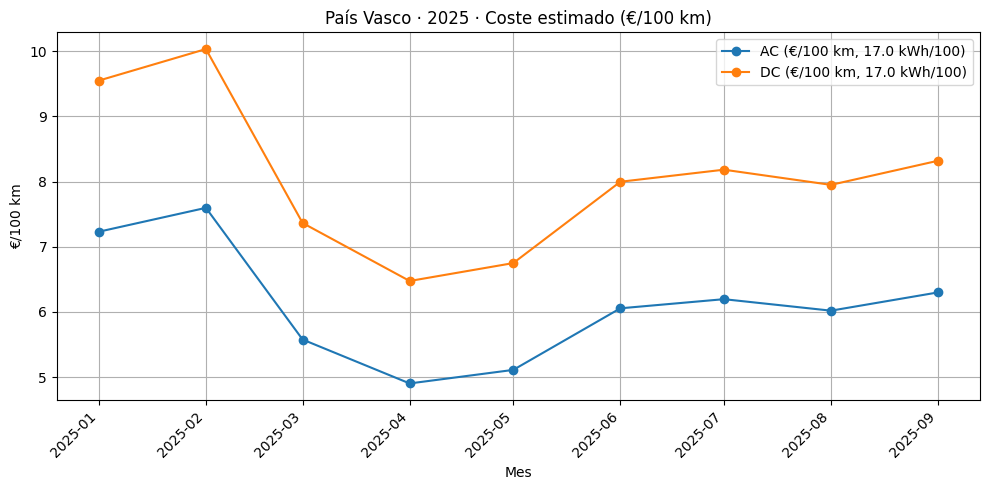

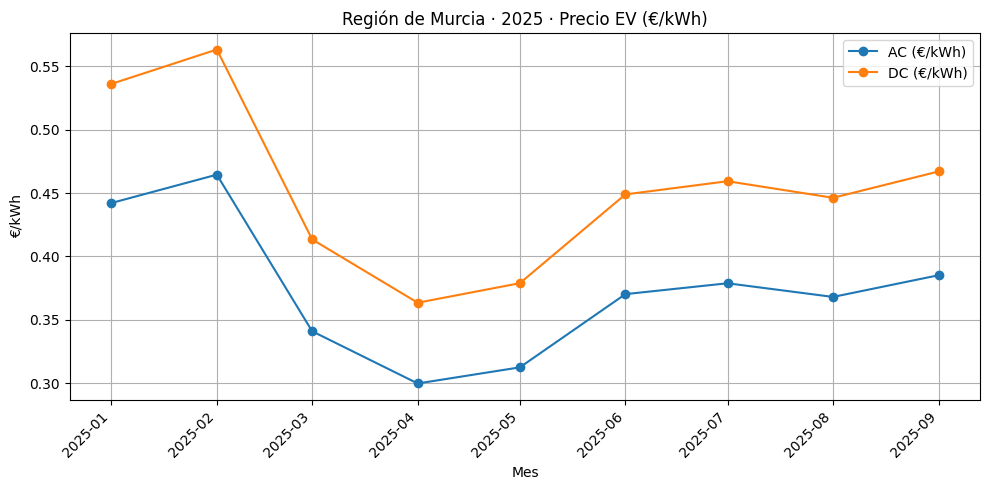

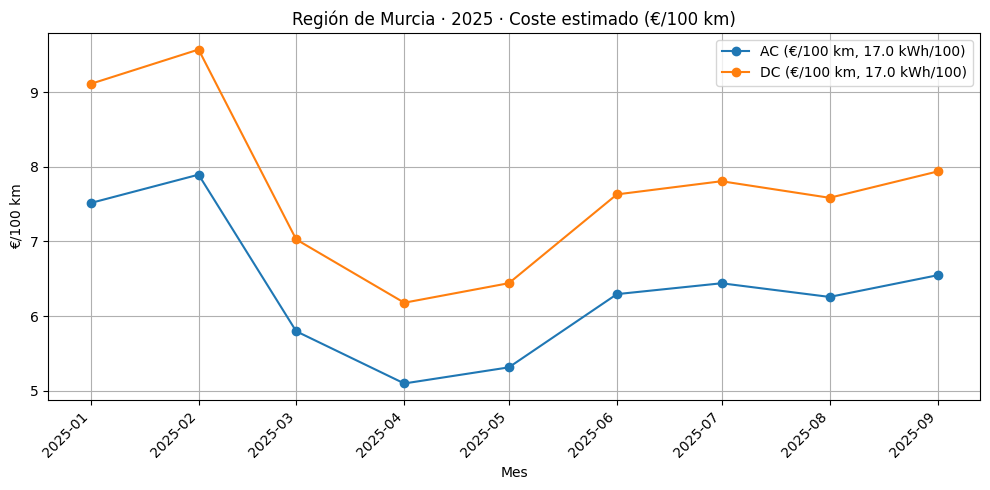

In [ ]:
prov_year = []
for p in PROVINCIAS:
    sub = df_wide[(df_wide["provincia"] == p) & (df_wide["month"].dt.year == YEAR)]
    if not sub.empty and sub[["AC","DC"]].notna().any().any():
        prov_year.append(p)

print(f"Generando curvas para {len(prov_year)} provincias")
for p in prov_year:
    plot_prov(df_wide, p, YEAR, kwh_per_100km=KWH_PER_100KM, save_figs=SAVE_FIGS)

In [ ]:
df_year = df_wide[df_wide["month"].dt.year == YEAR].copy()
df_year = df_year.sort_values(["provincia", "month"]).reset_index(drop=True)
for col in ["AC", "DC"]:
    if col not in df_year.columns:
        df_year[col] = pd.NA

df_long = df_year.melt(
    id_vars=["month", "provincia"], value_vars=["AC", "DC"],
    var_name="band", value_name="eur_kWh"
).sort_values(["provincia", "month", "band"]).reset_index(drop=True)

df_long["month_str"] = df_long["month"].dt.strftime("%Y-%m")
df_year["month_str"] = df_year["month"].dt.strftime("%Y-%m")

ac_matrix = (
    df_long[df_long["band"] == "AC"]
      .pivot_table(index="provincia", columns="month_str", values="eur_kWh", aggfunc="first")
      .sort_index()
)
dc_matrix = (
    df_long[df_long["band"] == "DC"]
      .pivot_table(index="provincia", columns="month_str", values="eur_kWh", aggfunc="first")
      .sort_index()
)
combo = (
    df_long.pivot_table(index="provincia", columns=["month_str", "band"], values="eur_kWh", aggfunc="first")
          .sort_index(axis=1)
          .sort_index(axis=0)
)
combo_flat = combo.copy()
combo_flat.columns = [f"{m}_{b}" for (m, b) in combo_flat.columns]

ac_matrix_style = ac_matrix.style.format("{:.3f}").set_caption(f"EV €/kWh (AC) por provincia · {YEAR}")
dc_matrix_style = dc_matrix.style.format("{:.3f}").set_caption(f"EV €/kWh (DC) por provincia · {YEAR}")
combo_flat_style = combo_flat.style.format("{:.3f}").set_caption(f"EV €/kWh (AC/DC) por provincia · {YEAR}")



Filas (long): 324


,month,ccaa,band,eur_kWh,month_str
0,2025-01-01,Andalucía,AC,0.434227,2025-01
1,2025-01-01,Andalucía,DC,0.553400,2025-01
2,2025-02-01,Andalucía,AC,0.456223,2025-02
3,2025-02-01,Andalucía,DC,0.581433,2025-02
4,2025-03-01,Andalucía,AC,0.334835,2025-03


In [ ]:
ac_csv = DATA_DIR / f"ev_table_provincias_AC_{YEAR}.csv"
dc_csv = DATA_DIR / f"ev_table_provincias_DC_{YEAR}.csv"
combo_csv = DATA_DIR / f"ev_table_provincias_ACDC_{YEAR}.csv"
long_csv = DATA_DIR / f"ev_table_provincias_long_{YEAR}.csv"

ac_matrix.to_csv(ac_csv, encoding="utf-8")
dc_matrix.to_csv(dc_csv, encoding="utf-8")
combo_flat.to_csv(combo_csv, encoding="utf-8")
df_long[["month_str","provincia","band","eur_kWh"]].to_csv(long_csv, index=False, encoding="utf-8")

print("[OK] Guardados:")
print(" -", ac_csv)
print(" -", dc_csv)
print(" -", combo_csv)
print(" -", long_csv)

month_str,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09
ccaa,,,,,,,,,
Andalucía,0.434,0.456,0.335,0.294,0.307,0.364,0.372,0.361,0.378
Aragón,0.442,0.465,0.341,0.300,0.313,0.370,0.379,0.368,0.385
Asturias,0.473,0.497,0.365,0.321,0.334,0.396,0.405,0.394,0.412
Canarias,0.424,0.446,0.327,0.288,0.300,0.355,0.363,0.353,0.370
Cantabria,0.401,0.421,0.309,0.272,0.283,0.335,0.343,0.333,0.349
Castilla y León,0.434,0.456,0.335,0.294,0.307,0.364,0.372,0.361,0.378
Castilla-La Mancha,0.454,0.477,0.350,0.308,0.321,0.380,0.389,0.378,0.395
Cataluña,0.442,0.465,0.341,0.300,0.313,0.370,0.379,0.368,0.385
Ceuta,0.287,0.302,0.221,0.195,0.203,0.240,0.246,0.239,0.250
